# exp410 Partial Dependence Plot (PDP) Analysis

**Context:** Model-interpretation notebook for the production exp410 RF
probability model. Unlike feature importance (which only ranks how much
a feature matters, not the direction/shape of its effect), Partial
Dependence Plots show the marginal effect of each covariate on predicted
peat probability, holding all other covariates at their mean value --
i.e. this answers "does higher wetness index increase or decrease
predicted peat probability, and is the relationship linear, threshold-
like, or non-monotonic?" for each of the top features.

Uses fold 0's model as representative (rather than an ensemble across
all 5 folds) and a random background sample of the training data (rather
than the full ~57K points) purely for PDP computation speed.

This notebook is diagnostic/interpretive -- it doesn't produce a
production artifact, but the resulting plots are good candidates for the
write-up's model-behavior discussion (e.g. explaining *why* wetness
index or distance-to-water drive predictions the way they do).


In [1]:
# Cell 1 — Imports and config
# Partial Dependence Plots for exp410 (peat probability)
# PDPs show the marginal effect of each feature on predictions
# holding all other features at their mean — reveals direction and
# shape of relationships that feature importance alone cannot show

import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.inspection import PartialDependenceDisplay
import warnings
warnings.filterwarnings('ignore')

BASE       = '/scratch.global/ocon0444/peat_modeling'
MDL_DIR    = os.path.join(BASE, '03_models')
RES_DIR    = os.path.join(BASE, '05_results')
CSV_PATH   = os.path.join(BASE, '00_data/processed/binary_peat_features_0_20_dropped.csv')
EXP410_DIR = os.path.join(MDL_DIR, 'exp410')

N_FOLDS      = 5
RANDOM_STATE = 42
PROB_THRESH  = 0.33

print('Ready.')

Ready.


In [2]:
# Cell 2 — Load exp410 model and feature set

with open(os.path.join(EXP410_DIR, 'feature_list.json')) as f:
    meta = json.load(f)
feature_cols = meta['features']
print(f'exp410 features: {len(feature_cols)}')
print(f'Features: {feature_cols}')

# Load fold models — use fold 0 for PDPs (representative single model)
# PDPs on single tree are faster and representative for interpretation
model = pickle.load(open(os.path.join(EXP410_DIR, 'model_fold_0.pkl'), 'rb'))
print(f'\nLoaded exp410 fold 0 model')
print(f'n_estimators: {model.n_estimators}')

exp410 features: 41
Features: ['minnesota_dem_10m', 'slope', 'aspect', 'hillshade', 'planCurvature', 'profileCurvature', 'maximalCurvature', 'd8FlowAccumulation', 'devfrommeanelev_4m', 'devfrommeanelev_8m', 'devfrommeanelev_16m', 'relativeTopographicPosition_4m', 'dist_to_water_10m', 'dist_to_stream_10m', 'prism_ppt_mn', 'prism_tmax_july_mn', 's2_spring_B02', 's2_spring_B06', 's2_spring_NDVI', 's2_spring_SWDI', 's2_summer_B02', 's2_summer_B06', 's2_summer_B11', 's2_summer_NDVI', 's2_summer_SWDI', 's2_fall_B02', 's2_fall_B06', 's2_fall_NDVI', 's2_fall_SWDI', 'dist_to_road_detailed_10m', 'tc_spring_TCB', 'tc_spring_TCG', 'tc_spring_TCW', 'tc_summer_TCB', 'tc_summer_TCG', 'tc_summer_TCW', 'tc_fall_TCB', 'tc_fall_TCG', 'tc_fall_TCW', 'mn_nwi_cowardin_0', 'mn_nwi_binary']

Loaded exp410 fold 0 model
n_estimators: 200


In [4]:
# Cell 3 — Load and prep training data for PDP background sample
# PDPs need a background dataset to marginalize over
# Use a random sample for speed — full dataset is slow

print('Loading binary peat CSV...')
df_all = pd.read_csv(CSV_PATH, low_memory=False)
print(f'  Shape: {df_all.shape}')

# NWI columns already one-hot encoded in extracted CSVs
# mn_nwi_cowardin_1 and _2 = wetland classes (equivalent to mn_nwi_binary)
# mn_nwi_cowardin_0 already exists directly
if 'mn_nwi_cowardin_10m' in df_all.columns:
    # Raw raster value present — derive one-hots
    df_all['mn_nwi_binary']     = ((df_all['mn_nwi_cowardin_10m']==1)|(df_all['mn_nwi_cowardin_10m']==2)).astype(int)
    df_all['mn_nwi_cowardin_0'] = (df_all['mn_nwi_cowardin_10m']==0).astype(int)
else:
    # Already one-hot encoded in extracted CSV
    df_all['mn_nwi_binary'] = (
        df_all.get('mn_nwi_cowardin_1', 0) + df_all.get('mn_nwi_cowardin_2', 0)
    ).clip(0, 1)
    # mn_nwi_cowardin_0 already present — no action needed
    print('NWI columns already one-hot encoded in CSV')

# Filter to valid rows
df = df_all[df_all['minnesota_dem_10m'].notna()].copy().reset_index(drop=True)
X_full = df[feature_cols].apply(pd.to_numeric, errors='coerce')
X_full = X_full.fillna(X_full.median())
y_full = df['peat_binary'].values if 'peat_binary' in df.columns else np.zeros(len(df))

# Random sample for PDP background (5000 rows is sufficient)
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_full), size=min(5000, len(X_full)), replace=False)
X_sample = X_full.iloc[sample_idx]

print(f'  PDP background sample: {len(X_sample):,} rows')
print(f'  Peat prevalence in sample: {y_full[sample_idx].mean()*100:.1f}%')

Loading binary peat CSV...
  Shape: (96744, 168)
NWI columns already one-hot encoded in CSV
  PDP background sample: 5,000 rows
  Peat prevalence in sample: 18.4%


In [5]:
# Cell 4 — Feature importance reference
# Load pre-computed importance to identify top 10 features for PDPs

imp_path = os.path.join(RES_DIR, 'exp410')
# Compute from model if file doesn't exist
imp = model.feature_importances_
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': imp})\
           .sort_values('importance', ascending=False)

top10 = imp_df.head(10)['feature'].tolist()
print('Top 10 features by importance:')
for i, (feat, val) in enumerate(zip(imp_df['feature'].head(10),
                                     imp_df['importance'].head(10)), 1):
    print(f'  {i:>2}. {feat:<40} {val:.4f}')

# Feature labels for cleaner plot titles
FEAT_LABELS = {
    'minnesota_dem_10m':              'Elevation (m)',
    'relativeTopographicPosition_16m':'Relative Topographic Position (16m)',
    'dist_to_water_10m':              'Distance to Water (m)',
    'dist_to_stream_10m':             'Distance to Stream (m)',
    'dist_to_road_detailed_10m':      'Distance to Road (m)',
    'prism_ppt_mn':                   'Mean Annual Precip (mm)',
    'prism_tmax_july_mn':             'July Max Temp (C)',
    'prism_tmean_mn':                 'Mean Annual Temp (C)',
    'prism_tmin_january_mn':          'January Min Temp (C)',
    's2_spring_SWDI':                 'Spring SWDI (Sentinel-2)',
    's2_summer_B02':                  'Summer Band 2 Blue',
    's2_summer_B07':                  'Summer Band 7 Red Edge',
    's2_summer_NDVI':                 'Summer NDVI',
    'tc_spring_TCG':                  'Spring Tasseled Cap Greenness',
    'tc_spring_TCW':                  'Spring Tasseled Cap Wetness',
    'mn_nwi_binary':                  'NWI Binary',
    'mn_nwi_cowardin_0':              'NWI Cowardin 0',
}

Top 10 features by importance:
   1. slope                                    0.1541
   2. maximalCurvature                         0.0817
   3. prism_tmax_july_mn                       0.0800
   4. s2_summer_B06                            0.0443
   5. tc_spring_TCW                            0.0430
   6. tc_spring_TCB                            0.0409
   7. mn_nwi_binary                            0.0344
   8. mn_nwi_cowardin_0                        0.0338
   9. tc_summer_TCB                            0.0334
  10. tc_summer_TCG                            0.0308


Computing individual PDPs for top 10 features...
(This may take 1-2 minutes)


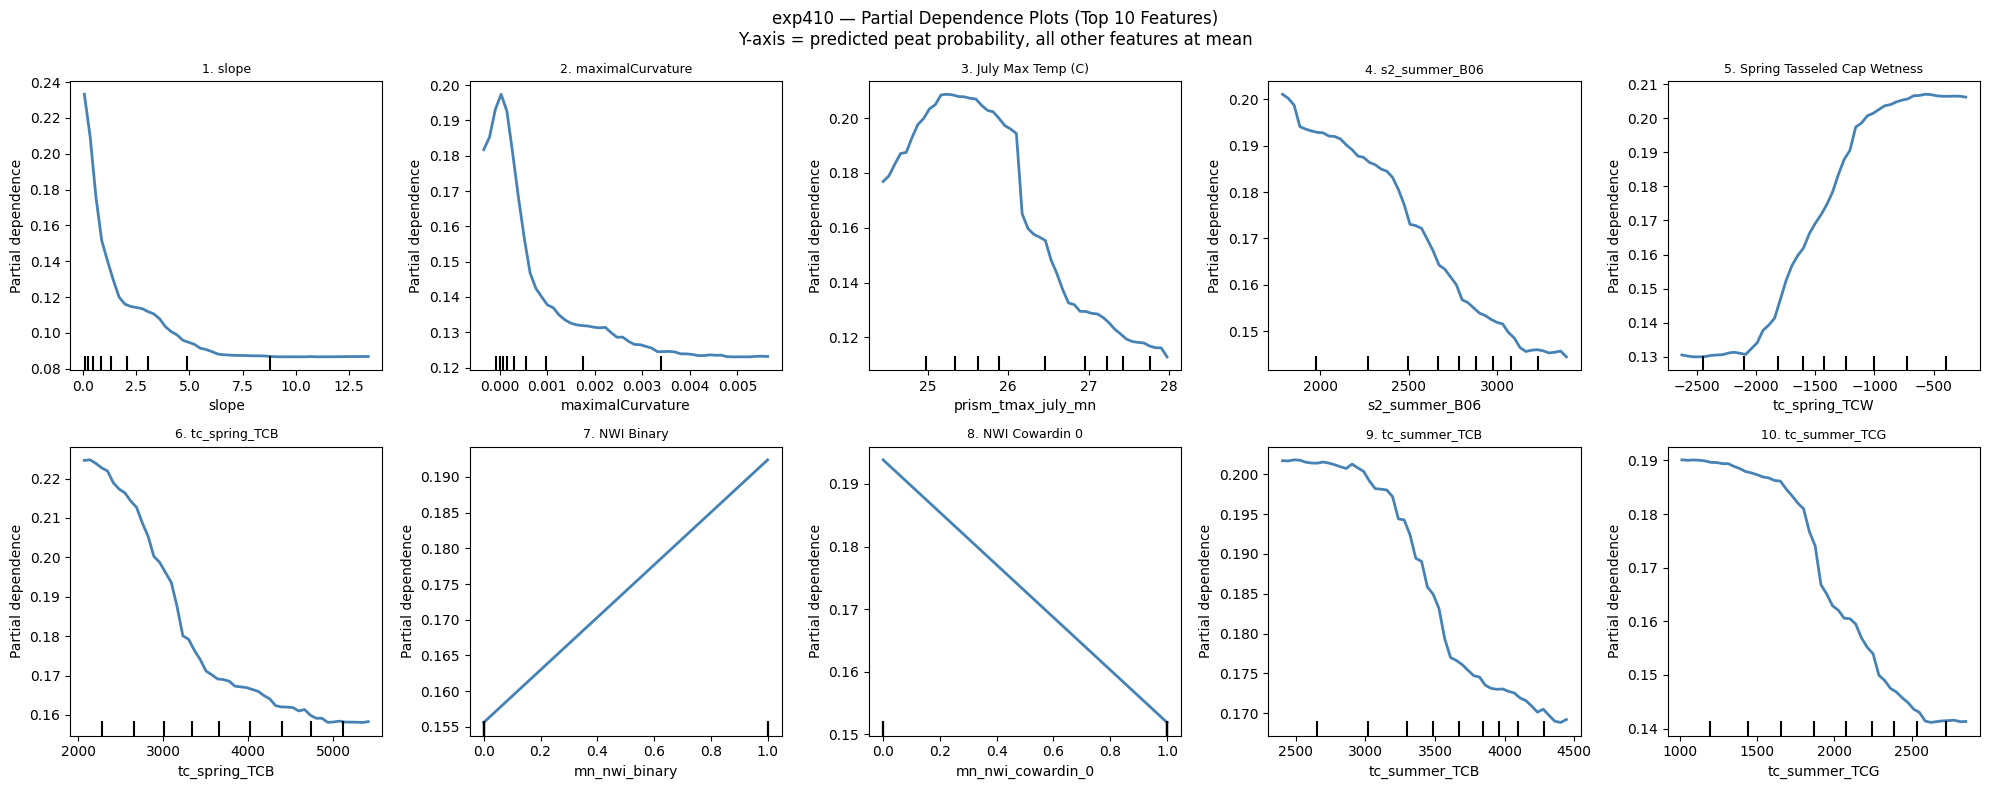

Saved: exp410_pdp_top10.png


In [6]:
# Cell 5 — Individual PDPs for top 10 features
# Shows marginal effect of each feature on peat probability
# X axis = feature value, Y axis = predicted peat probability
# All other features held at their mean (marginalized)

print('Computing individual PDPs for top 10 features...')
print('(This may take 1-2 minutes)')

top10_idx = [feature_cols.index(f) for f in top10 if f in feature_cols]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (feat_idx, feat_name) in enumerate(zip(top10_idx, top10)):
    disp = PartialDependenceDisplay.from_estimator(
        model, X_sample,
        features=[feat_idx],
        feature_names=feature_cols,
        target=1,  # class 1 = peat present
        kind='average',
        ax=axes[i],
        line_kw={'color': 'steelblue', 'lw': 2},
        grid_resolution=50,
    )
    label = FEAT_LABELS.get(feat_name, feat_name)
    axes[i].set_title(f'{i+1}. {label}', fontsize=9)
    axes[i].set_xlabel(label, fontsize=8)
    axes[i].set_ylabel('Peat Probability' if i % 5 == 0 else '', fontsize=8)
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(labelsize=7)

plt.suptitle('exp410 — Partial Dependence Plots (Top 10 Features)\n'
             'Y-axis = predicted peat probability, all other features at mean',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'exp410_pdp_top10.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp410_pdp_top10.png')

Computing 2D PDPs for 2 feature pairs...
(This may take 2-4 minutes)


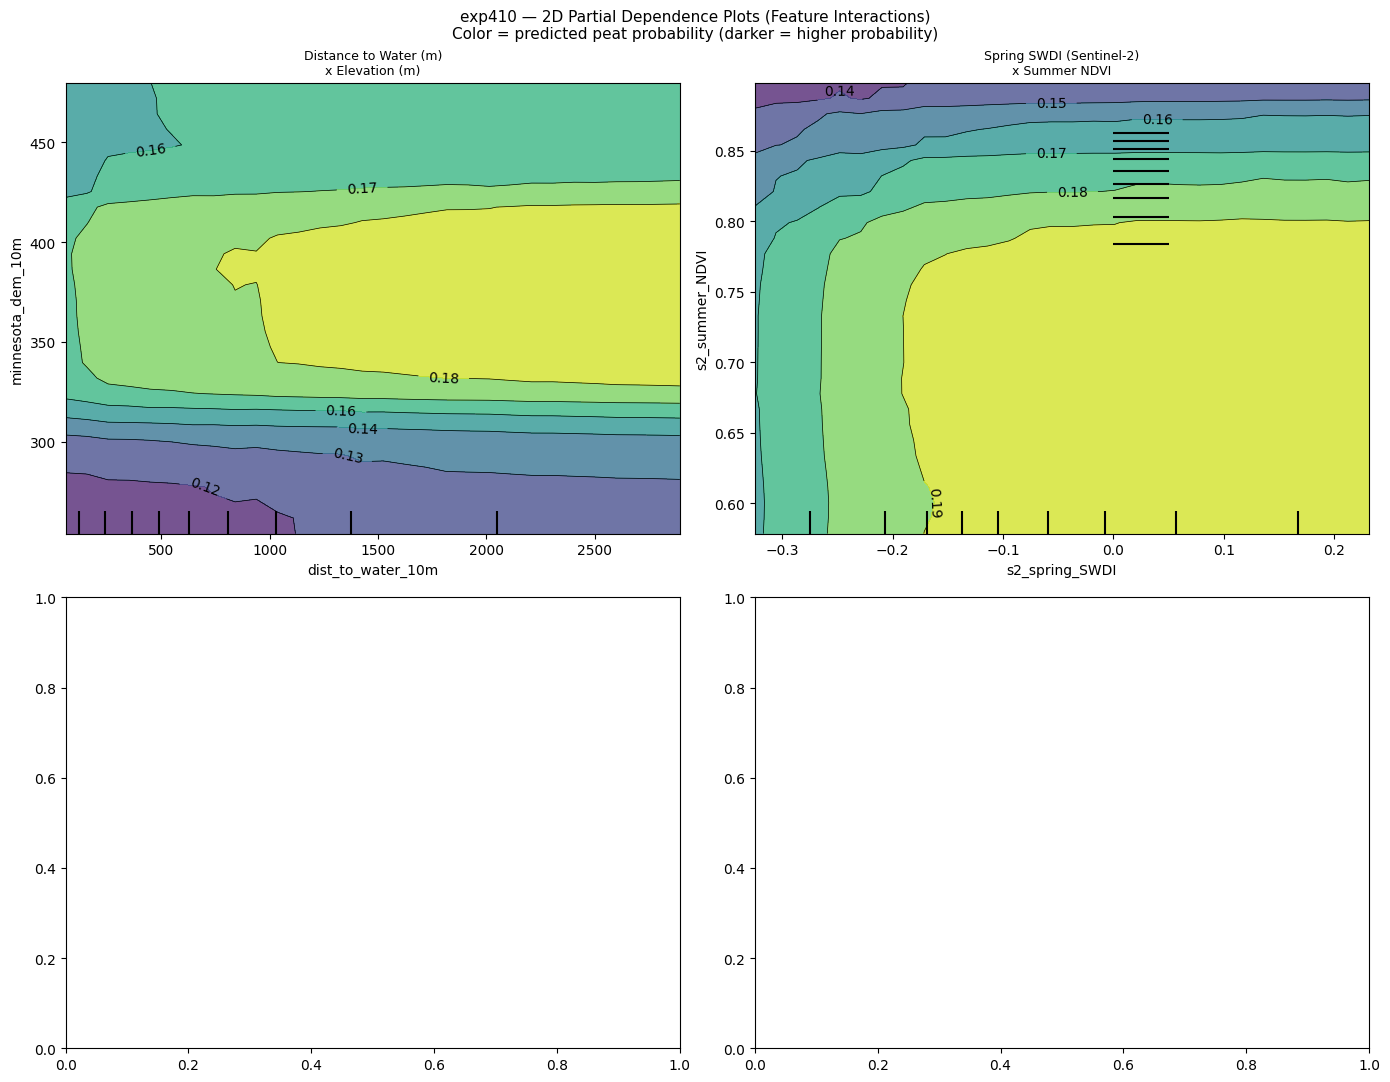

Saved: exp410_pdp_2d.png


In [7]:
# Cell 6 — 2D interaction PDPs
# Shows how pairs of features jointly influence peat probability
# Color = predicted peat probability
# Reveals interactions that 1D PDPs miss

# Feature pairs to investigate:
# 1. Precip x January min temp — climate envelope for peat formation
# 2. Distance to water x Elevation — topographic wetness proxy
# 3. Spring SWDI x Summer NDVI — spectral interaction
# 4. Precip x Relative Topo Position — climate x terrain

pair_candidates = [
    ('prism_ppt_mn',                   'prism_tmin_january_mn'),
    ('dist_to_water_10m',              'minnesota_dem_10m'),
    ('s2_spring_SWDI',                 's2_summer_NDVI'),
    ('prism_ppt_mn',                   'relativeTopographicPosition_16m'),
]

# Filter to pairs where both features are in the model
pairs = [(a,b) for a,b in pair_candidates
         if a in feature_cols and b in feature_cols]

print(f'Computing 2D PDPs for {len(pairs)} feature pairs...')
print('(This may take 2-4 minutes)')

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (feat_a, feat_b) in enumerate(pairs):
    idx_a = feature_cols.index(feat_a)
    idx_b = feature_cols.index(feat_b)
    label_a = FEAT_LABELS.get(feat_a, feat_a)
    label_b = FEAT_LABELS.get(feat_b, feat_b)

    disp = PartialDependenceDisplay.from_estimator(
        model, X_sample,
        features=[(idx_a, idx_b)],
        feature_names=feature_cols,
        target=1,
        kind='average',
        ax=axes[i],
        grid_resolution=30,
    )
    axes[i].set_xlabel(label_a, fontsize=9)
    axes[i].set_ylabel(label_b, fontsize=9)
    axes[i].set_title(f'{label_a}\nx {label_b}', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle('exp410 — 2D Partial Dependence Plots (Feature Interactions)\n'
             'Color = predicted peat probability (darker = higher probability)',
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, 'exp410_pdp_2d.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp410_pdp_2d.png')

In [8]:
# Cell 7 — Interpret PDP results
# Summarize key ecological insights from the PDPs

print('=== PDP Interpretation Guide ===')
print()
print('What to look for in 1D PDPs:')
print('  - Flat line = feature has little marginal effect (despite high importance)')
print('    (may still be important for splitting even if marginal effect is small)')
print('  - Monotonic increase/decrease = clear directional relationship')
print('  - Threshold behavior = probability jumps at a specific value')
print('  - Hump/valley shape = non-linear optimum')
print()
print('Expected relationships for MN peatlands:')
print('  prism_ppt_mn       : increasing — wetter climates support more peat')
print('  prism_tmin_january : increasing — colder winters reduce decomposition')
print('  dist_to_water      : decreasing — closer to water = higher peat prob')
print('  dist_to_stream     : decreasing — same as above')
print('  relativeTopoPos    : decreasing — low topographic positions accumulate water')
print('  elevation          : variable — depends on latitude x elevation interaction')
print('  tc_spring_TCW      : increasing — high wetness = higher peat prob')
print('  s2_summer_NDVI     : variable — moderate NDVI for bog/fen vegetation')
print()
print('If observed PDPs contradict expected relationships:')
print('  1. Feature may be acting as proxy for something else')
print('  2. Training data distribution may be constraining predictions')
print('  3. Extrapolation outside training range is unreliable')
print()
print('For 2D PDPs:')
print('  - If surface is flat in one direction = no interaction')
print('  - If surface has ridges/valleys = strong interaction')
print('  - Precip x temp interaction: high prob should be in cold/wet quadrant')

=== PDP Interpretation Guide ===

What to look for in 1D PDPs:
  - Flat line = feature has little marginal effect (despite high importance)
    (may still be important for splitting even if marginal effect is small)
  - Monotonic increase/decrease = clear directional relationship
  - Threshold behavior = probability jumps at a specific value
  - Hump/valley shape = non-linear optimum

Expected relationships for MN peatlands:
  prism_ppt_mn       : increasing — wetter climates support more peat
  prism_tmin_january : increasing — colder winters reduce decomposition
  dist_to_water      : decreasing — closer to water = higher peat prob
  dist_to_stream     : decreasing — same as above
  relativeTopoPos    : decreasing — low topographic positions accumulate water
  elevation          : variable — depends on latitude x elevation interaction
  tc_spring_TCW      : increasing — high wetness = higher peat prob
  s2_summer_NDVI     : variable — moderate NDVI for bog/fen vegetation

If observed